Data augmentation is a critical technique in machine learning for enhancing datasets by generating new data points from existing ones. It involves applying various transformations to the data to increase diversity and improve model generalization. Here's an overview of data augmentation techniques and their benefits:

### Techniques:

1. **Image Augmentation:**
   - Rotation: Rotating images by a certain angle.
   - Flipping: Mirroring images horizontally or vertically.
   - Scaling: Resizing images to different dimensions.
   - Cropping: Extracting portions of images.
   - Brightness/Contrast Adjustment: Changing brightness or contrast levels.

2. **Text Augmentation:**
   - Synonym Replacement: Replacing words with their synonyms.
   - Word Rearrangement: Shuffling word orders in sentences.
   - Adding Noise: Introducing typographical errors or random insertions/deletions.

3. **Audio Augmentation:**
   - Pitch Shifting: Altering the pitch of audio signals.
   - Time Stretching: Changing the speed of audio playback.
   - Adding Background Noise: Injecting random noise into audio clips.

### Benefits:

1. **Increased Dataset Diversity:**
   - By generating new data points with variations, data augmentation enhances the diversity of the dataset, enabling models to learn from a wider range of examples.

2. **Mitigation of Overfitting:**
   - Overfitting occurs when a model memorizes the training data instead of learning generalizable patterns. Data augmentation exposes the model to more varied data, helping to reduce overfitting by making it more robust to different inputs.

3. **Resource Savings:**
   - Instead of collecting entirely new data, data augmentation allows for the expansion of datasets using existing samples. This saves resources in terms of time, cost, and effort required for data collection.

### Widely Used Across Various Tasks:

1. **Computer Vision:**
   - Data augmentation is extensively used in tasks such as image classification, object detection, and segmentation to improve model performance and robustness.

2. **Natural Language Processing (NLP):**
   - Text augmentation techniques are applied in tasks like sentiment analysis, text classification, and language translation to increase dataset diversity and improve model generalization.

3. **Speech Recognition:**
   - Audio augmentation is crucial in tasks such as speech recognition and speaker identification to handle variations in speech patterns and environmental noise.

Overall, data augmentation is a versatile technique that plays a vital role in improving the performance and robustness of machine learning models across different domains.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile

zip_file_path = '/content/drive/MyDrive/DIP Project/sign language.zip'
extract_path =  '/content/drive/MyDrive/DIP Project/sign language'


with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Zip file '{zip_file_path}' has been extracted to '{extract_path}'.")

Zip file '/content/drive/MyDrive/DIP Project/sign language.zip' has been extracted to '/content/drive/MyDrive/DIP Project/sign language'.


## Augmentation

In [ ]:
from PIL import Image, ImageEnhance
import os
import zipfile

# Path to the folder containing the extracted images
input_folder = '/content/drive/MyDrive/DIP Project/sign language/dataset/characters'
output_folder = '/content/drive/MyDrive/DIP Project/augmented sign_language'
num_augmented_images = 200

# Create output folder if it doesn't exist
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

# Function to perform data augmentation
def augment_image(input_path, output_path):
    image = Image.open(input_path)

    # Apply various transformations (you can customize these)
    enhancer = ImageEnhance.Brightness(image)
    image = enhancer.enhance(1.5)  # Increase brightness

    enhancer = ImageEnhance.Contrast(image)
    image = enhancer.enhance(1.5)  # Increase contrast

    # Add more transformations as needed

    # Save augmented image
    image.save(output_path)

# Loop through each image and perform data augmentation
for root, dirs, files in os.walk(input_folder):
    for file in files:
        input_path = os.path.join(root, file)

        # Ignore non-image files (you may need to customize this based on your file types)
        if not input_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        # Get the character or file name (adjust this part based on your file naming)
        character = os.path.splitext(file)[0]

        # Create a subfolder for each character in the output folder
        character_output_folder = os.path.join(output_folder, character)
        if not os.path.exists(character_output_folder):
            os.makedirs(character_output_folder)

        for i in range(1, num_augmented_images + 1):
            output_path = os.path.join(character_output_folder, f"{character}_{i}.png")
            augment_image(input_path, output_path)

## Morphological(erosion and dilation)

In [ ]:
import cv2
import os

# Path to the folder containing augmented images
input_folder = '/content/drive/MyDrive/DIP Project/augmented sign_language'

# Output folder where morphologically processed images will be saved
output_folder_erosion = '/content/drive/MyDrive/DIP Project/morphological_processed_images_erosion'
output_folder_dilation = '/content/drive/MyDrive/DIP Project/morphological_processed_images_dilation'

# Create output folders if they don't exist
if not os.path.exists(output_folder_erosion):
    os.makedirs(output_folder_erosion)

if not os.path.exists(output_folder_dilation):
    os.makedirs(output_folder_dilation)

# Function to perform morphological operations
def morphological_operations(input_path, output_path, operation=cv2.MORPH_CLOSE):
    # Read the image
    image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)

    # Apply morphological operations (you can customize these)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    morph_result = cv2.morphologyEx(image, operation, kernel)

    # Save processed image
    cv2.imwrite(output_path, morph_result)

# Loop through each character and process augmented images
for root, dirs, files in os.walk(input_folder):
    for file in files:
        input_path = os.path.join(root, file)

        # Ignore non-image files (you may need to customize this based on your file types)
        if not input_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        # Get the character or file name (adjust this part based on your file naming)
        character = os.path.basename(os.path.dirname(input_path))

        # Create subfolders for each character in the output folders
        character_output_folder_erosion = os.path.join(output_folder_erosion, character)
        if not os.path.exists(character_output_folder_erosion):
            os.makedirs(character_output_folder_erosion)

        character_output_folder_dilation = os.path.join(output_folder_dilation, character)
        if not os.path.exists(character_output_folder_dilation):
            os.makedirs(character_output_folder_dilation)

        # Process each augmented image for erosion
        output_path_erosion = os.path.join(character_output_folder_erosion, f"{os.path.splitext(file)[0]}_erosion.png")
        morphological_operations(input_path, output_path_erosion, operation=cv2.MORPH_ERODE)

        # Process each augmented image for dilation
        output_path_dilation = os.path.join(character_output_folder_dilation, f"{os.path.splitext(file)[0]}_dilation.png")
        morphological_operations(input_path, output_path_dilation, operation=cv2.MORPH_DILATE)

## Edge Detection

In [ ]:
import cv2
import os

# Input folder containing images after erosion
input_folder_erosion = '/content/drive/MyDrive/DIP Project/morphological_processed_images_erosion'

# Output folders for edge detection using different operators
output_folder_canny = '/content/drive/MyDrive/DIP Project/erosion + canny'
output_folder_sobel = '/content/drive/MyDrive/DIP Project/erosion + sobel'
output_folder_prewitt = '/content/drive/MyDrive/DIP Project/erosion + prewitt'

# Create output folders if they don't exist
if not os.path.exists(output_folder_canny):
    os.makedirs(output_folder_canny)

if not os.path.exists(output_folder_sobel):
    os.makedirs(output_folder_sobel)

if not os.path.exists(output_folder_prewitt):
    os.makedirs(output_folder_prewitt)

# Function to perform edge detection using different operators
def edge_detection(input_path, output_path, operator):
    # Read the image
    image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)

    # Apply edge detection using different operators
    if operator == 'canny':
        edge_result = cv2.Canny(image, 100, 200)
    elif operator == 'sobel':
        sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
        edge_result = cv2.magnitude(sobelx, sobely)
    elif operator == 'prewitt':
        kernelx = cv2.getDerivKernels(1, 0, 3, normalize=True)
        kernely = cv2.getDerivKernels(0, 1, 3, normalize=True)
        prewittx = cv2.filter2D(image, cv2.CV_64F, kernelx[0] * kernely[0].T)
        prewitty = cv2.filter2D(image, cv2.CV_64F, kernelx[0].T * kernely[0])
        edge_result = cv2.magnitude(prewittx, prewitty)
    else:
        raise ValueError("Invalid edge detection operator")

    # Save processed image
    cv2.imwrite(output_path, edge_result)

# Loop through each character and process images after erosion
for root, dirs, files in os.walk(input_folder_erosion):
    for file in files:
        input_path = os.path.join(root, file)

        # Ignore non-image files (you may need to customize this based on your file types)
        if not input_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        # Get the character or file name (adjust this part based on your file naming)
        character = os.path.basename(os.path.dirname(input_path))

        # Create subfolders for each character in the output folders
        character_output_folder_canny = os.path.join(output_folder_canny, character)
        if not os.path.exists(character_output_folder_canny):
            os.makedirs(character_output_folder_canny)

        character_output_folder_sobel = os.path.join(output_folder_sobel, character)
        if not os.path.exists(character_output_folder_sobel):
            os.makedirs(character_output_folder_sobel)

        character_output_folder_prewitt = os.path.join(output_folder_prewitt, character)
        if not os.path.exists(character_output_folder_prewitt):
            os.makedirs(character_output_folder_prewitt)

        # Process each image for Canny edge detection
        output_path_canny = os.path.join(character_output_folder_canny, f"{os.path.splitext(file)[0]}_canny.png")
        edge_detection(input_path, output_path_canny, 'canny')

        # Process each image for Sobel edge detection
        output_path_sobel = os.path.join(character_output_folder_sobel, f"{os.path.splitext(file)[0]}_sobel.png")
        edge_detection(input_path, output_path_sobel, 'sobel')

        # Process each image for Prewitt edge detection
        output_path_prewitt = os.path.join(character_output_folder_prewitt, f"{os.path.splitext(file)[0]}_prewitt.png")
        edge_detection(input_path, output_path_prewitt, 'prewitt')

In [ ]:
import cv2
import os

# Input folder containing images after dilation
input_folder_dilation = '/content/drive/MyDrive/DIP Project/morphological_processed_images_dilation'

# Output folders for edge detection using different operators
output_folder_canny = '/content/drive/MyDrive/DIP Project/dilation + canny'
output_folder_sobel = '/content/drive/MyDrive/DIP Project/dilation + sobel'
output_folder_prewitt = '/content/drive/MyDrive/DIP Project/dilation + prewitt'

# Create output folders if they don't exist
if not os.path.exists(output_folder_canny):
    os.makedirs(output_folder_canny)

if not os.path.exists(output_folder_sobel):
    os.makedirs(output_folder_sobel)

if not os.path.exists(output_folder_prewitt):
    os.makedirs(output_folder_prewitt)

# Function to perform edge detection using different operators
def edge_detection(input_path, output_path, operator):
    # Read the image
    image = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)

    # Apply edge detection using different operators
    if operator == 'canny':
        edge_result = cv2.Canny(image, 100, 200)
    elif operator == 'sobel':
        sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)
        edge_result = cv2.magnitude(sobelx, sobely)
    elif operator == 'prewitt':
        kernelx = cv2.getDerivKernels(1, 0, 3, normalize=True)
        kernely = cv2.getDerivKernels(0, 1, 3, normalize=True)
        prewittx = cv2.filter2D(image, cv2.CV_64F, kernelx[0] * kernely[0].T)
        prewitty = cv2.filter2D(image, cv2.CV_64F, kernelx[0].T * kernely[0])
        edge_result = cv2.magnitude(prewittx, prewitty)
    else:
        raise ValueError("Invalid edge detection operator")

    # Save processed image
    cv2.imwrite(output_path, edge_result)

# Loop through each character and process images after dilation
for root, dirs, files in os.walk(input_folder_dilation):
    for file in files:
        input_path = os.path.join(root, file)

        # Ignore non-image files (you may need to customize this based on your file types)
        if not input_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        # Get the character or file name (adjust this part based on your file naming)
        character = os.path.basename(os.path.dirname(input_path))

        # Create subfolders for each character in the output folders
        character_output_folder_canny = os.path.join(output_folder_canny, character)
        if not os.path.exists(character_output_folder_canny):
            os.makedirs(character_output_folder_canny)

        character_output_folder_sobel = os.path.join(output_folder_sobel, character)
        if not os.path.exists(character_output_folder_sobel):
            os.makedirs(character_output_folder_sobel)

        character_output_folder_prewitt = os.path.join(output_folder_prewitt, character)
        if not os.path.exists(character_output_folder_prewitt):
            os.makedirs(character_output_folder_prewitt)

        # Process each image for Canny edge detection
        output_path_canny = os.path.join(character_output_folder_canny, f"{os.path.splitext(file)[0]}_canny.png")
        edge_detection(input_path, output_path_canny, 'canny')

        # Process each image for Sobel edge detection
        output_path_sobel = os.path.join(character_output_folder_sobel, f"{os.path.splitext(file)[0]}_sobel.png")
        edge_detection(input_path, output_path_sobel, 'sobel')

        # Process each image for Prewitt edge detection
        output_path_prewitt = os.path.join(character_output_folder_prewitt, f"{os.path.splitext(file)[0]}_prewitt.png")
        edge_detection(input_path, output_path_prewitt, 'prewitt')

## CNN Modal Create

1. erosion + canny

Found 5760 images belonging to 36 classes.
Epoch 1/30
144/144 [==============================] - 56s 383ms/step - loss: 3.2070 - accuracy: 0.1252 - val_loss: 2.1589 - val_accuracy: 0.4097
Epoch 2/30
144/144 [==============================] - 60s 420ms/step - loss: 1.6941 - accuracy: 0.5117 - val_loss: 0.9939 - val_accuracy: 0.7188
Epoch 3/30
144/144 [==============================] - 60s 414ms/step - loss: 0.8480 - accuracy: 0.7444 - val_loss: 0.5069 - val_accuracy: 0.8533
Epoch 4/30
144/144 [==============================] - 61s 421ms/step - loss: 0.4787 - accuracy: 0.8492 - val_loss: 0.4337 - val_accuracy: 0.8698
Epoch 5/30
144/144 [==============================] - 61s 421ms/step - loss: 0.3108 - accuracy: 0.9030 - val_loss: 0.3469 - val_accuracy: 0.9036
Epoch 6/30
144/144 [==============================] - 59s 406ms/step - loss: 0.2079 - accuracy: 0.9321 - val_loss: 0.3361 - val_accuracy: 0.9123
Epoch 7/30
144/144 [==============================] - 58s 405ms/step - loss: 0.1904 - a

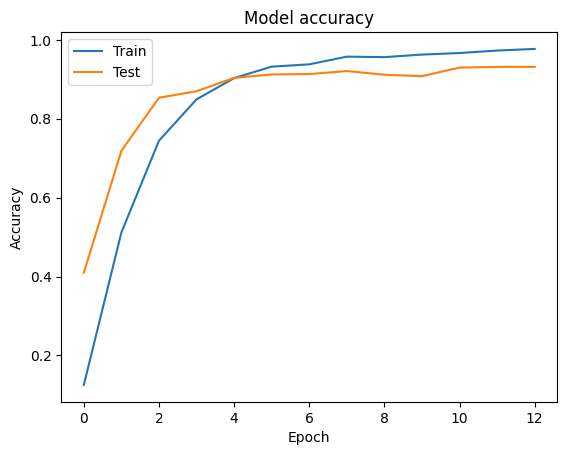

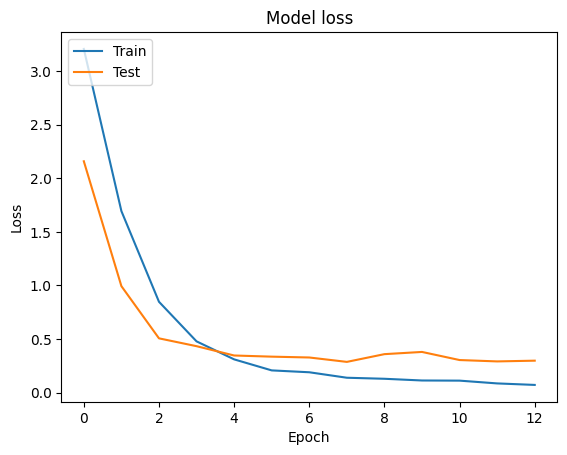

36/36 [==============================] - 4s 118ms/step
Classification Report:
              precision    recall  f1-score   support

         0.0       0.96      0.85      0.90        27
         1.0       0.90      0.93      0.91        28
         2.0       0.87      0.91      0.89        22
         3.0       0.97      0.85      0.91        34
         4.0       0.94      0.97      0.95        30
         5.0       0.94      0.94      0.94        32
         6.0       0.84      0.98      0.90        43
         7.0       0.94      0.94      0.94        31
         8.0       0.97      1.00      0.98        30
         9.0       0.94      0.97      0.96        33
        10.0       0.83      0.87      0.85        39
        11.0       0.94      0.80      0.86        40
        12.0       0.97      0.97      0.97        30
        13.0       0.94      0.97      0.96        33
        14.0       1.00      0.90      0.95        31
        15.0       0.93      1.00      0.96        37
   

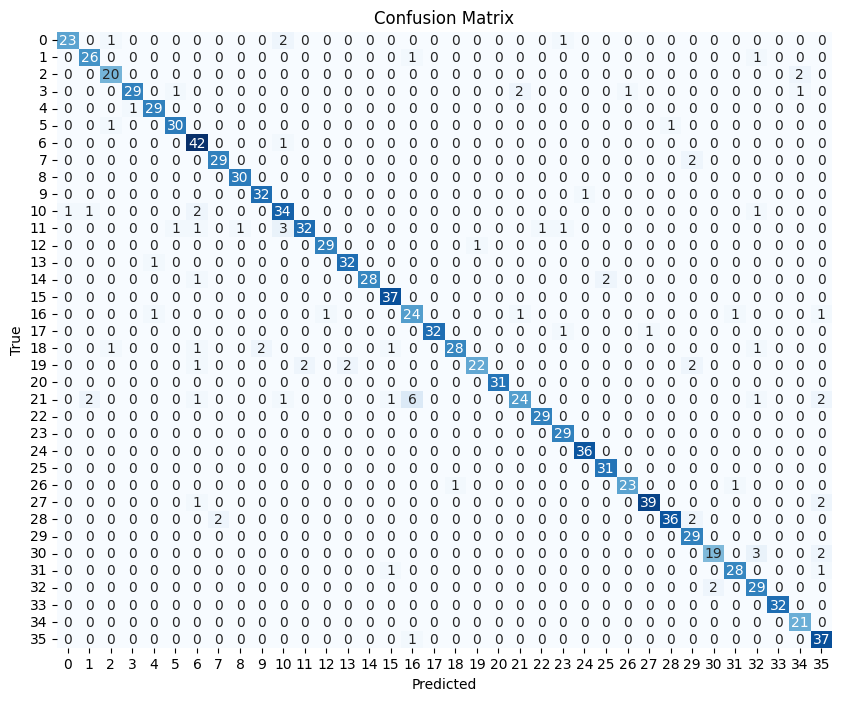

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from keras.callbacks import EarlyStopping

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/erosion + canny'

def load_images(dataset_path, batch_size=32):
    # Image data generator for loading images in batches with resizing and augmentation
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2  # 20% of the data will be used for validation
    )

    # Load and preprocess images using the data generator
    image_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Get the number of classes
    num_classes = image_generator.num_classes

    # Load images and labels
    images, labels = [], []
    for _ in range(len(image_generator)):
        batch_images, batch_labels = next(image_generator)
        images.extend(batch_images)
        labels.extend(batch_labels)

    return np.array(images), np.array(labels), num_classes

# Load and preprocess images
images, labels, num_classes = load_images(dataset_path)

# Split dataset into train and test sets
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)

# Define CNN model with dropout layers
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),  # Adding dropout with a rate of 0.5
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping callback
history = model.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels), callbacks=[early_stopping])

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# 1. Make Predictions
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


2. erosion + sobel

Found 5760 images belonging to 36 classes.
Epoch 1/30
144/144 [==============================] - 53s 364ms/step - loss: 3.1785 - accuracy: 0.1328 - val_loss: 1.9200 - val_accuracy: 0.4601
Epoch 2/30
144/144 [==============================] - 58s 402ms/step - loss: 1.5452 - accuracy: 0.5477 - val_loss: 0.8312 - val_accuracy: 0.7648
Epoch 3/30
144/144 [==============================] - 58s 405ms/step - loss: 0.7320 - accuracy: 0.7697 - val_loss: 0.4726 - val_accuracy: 0.8646
Epoch 4/30
144/144 [==============================] - 57s 396ms/step - loss: 0.3579 - accuracy: 0.8791 - val_loss: 0.2733 - val_accuracy: 0.9175
Epoch 5/30
144/144 [==============================] - 59s 410ms/step - loss: 0.2338 - accuracy: 0.9271 - val_loss: 0.2716 - val_accuracy: 0.9227
Epoch 6/30
144/144 [==============================] - 60s 416ms/step - loss: 0.1637 - accuracy: 0.9425 - val_loss: 0.2001 - val_accuracy: 0.9375
Epoch 7/30
144/144 [==============================] - 59s 408ms/step - loss: 0.1220 - a

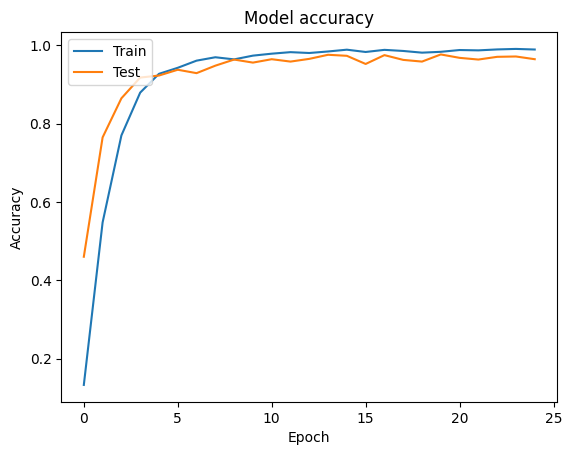

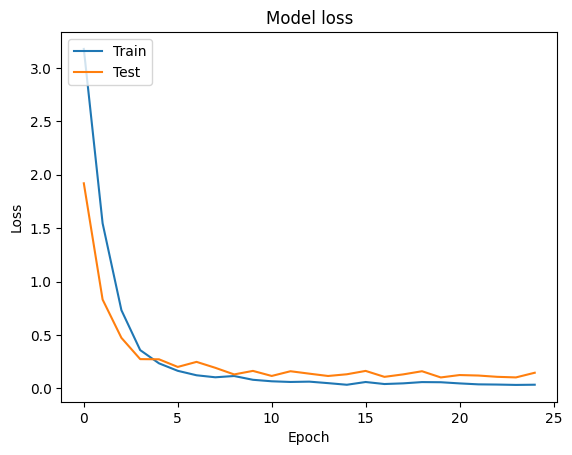

36/36 [==============================] - 3s 92ms/step
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.99        35
         1.0       1.00      1.00      1.00        30
         2.0       1.00      1.00      1.00        36
         3.0       1.00      1.00      1.00        34
         4.0       1.00      1.00      1.00        31
         5.0       1.00      0.91      0.96        35
         6.0       0.97      1.00      0.98        31
         7.0       0.97      1.00      0.99        38
         8.0       0.96      0.96      0.96        26
         9.0       1.00      0.97      0.98        33
        10.0       0.92      1.00      0.96        33
        11.0       0.94      0.89      0.91        35
        12.0       0.97      1.00      0.99        33
        13.0       1.00      1.00      1.00        28
        14.0       0.88      0.97      0.92        30
        15.0       1.00      1.00      1.00        21
    

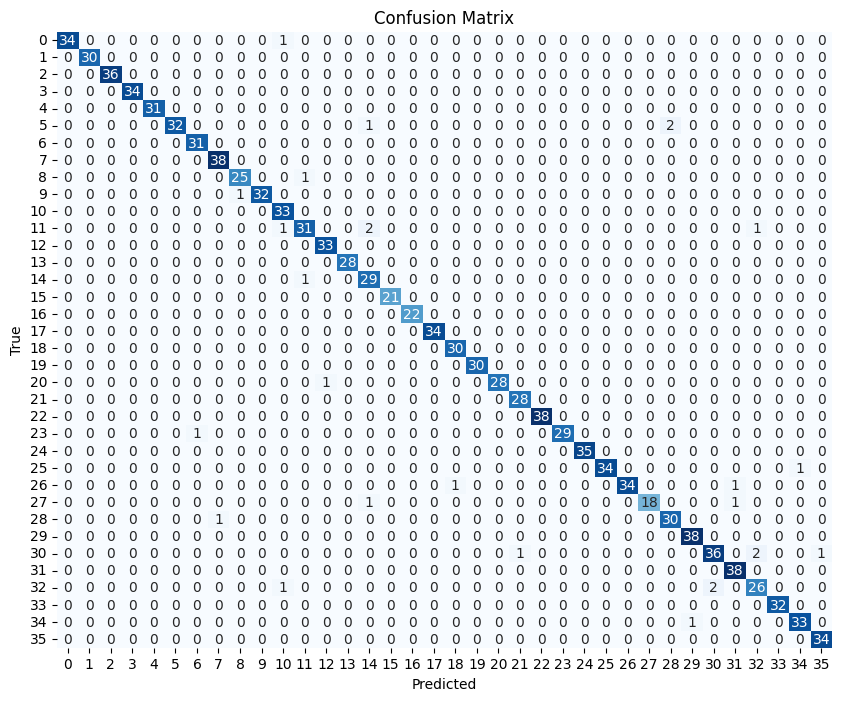

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from keras.callbacks import EarlyStopping

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/erosion + sobel'

def load_images(dataset_path, batch_size=32):
    # Image data generator for loading images in batches with resizing and augmentation
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2  # 20% of the data will be used for validation
    )

    # Load and preprocess images using the data generator
    image_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Get the number of classes
    num_classes = image_generator.num_classes

    # Load images and labels
    images, labels = [], []
    for _ in range(len(image_generator)):
        batch_images, batch_labels = next(image_generator)
        images.extend(batch_images)
        labels.extend(batch_labels)

    return np.array(images), np.array(labels), num_classes

# Load and preprocess images
images, labels, num_classes = load_images(dataset_path)

# Split dataset into train and test sets
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)

# Define CNN model with dropout layers
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),  # Adding dropout with a rate of 0.5
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping callback
history = model.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels), callbacks=[early_stopping])

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# 1. Make Predictions
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

3. erosion + prewitt

Found 5760 images belonging to 36 classes.
Epoch 1/30
144/144 [==============================] - 51s 345ms/step - loss: 2.8508 - accuracy: 0.1975 - val_loss: 1.8362 - val_accuracy: 0.4479
Epoch 2/30
144/144 [==============================] - 50s 347ms/step - loss: 1.2778 - accuracy: 0.6085 - val_loss: 0.6255 - val_accuracy: 0.8160
Epoch 3/30
144/144 [==============================] - 50s 349ms/step - loss: 0.6085 - accuracy: 0.8095 - val_loss: 0.4777 - val_accuracy: 0.8602
Epoch 4/30
144/144 [==============================] - 60s 414ms/step - loss: 0.3495 - accuracy: 0.8900 - val_loss: 0.3104 - val_accuracy: 0.9106
Epoch 5/30
144/144 [==============================] - 61s 427ms/step - loss: 0.2706 - accuracy: 0.9175 - val_loss: 0.2067 - val_accuracy: 0.9470
Epoch 6/30
144/144 [==============================] - 60s 415ms/step - loss: 0.1871 - accuracy: 0.9421 - val_loss: 0.1657 - val_accuracy: 0.9488
Epoch 7/30
144/144 [==============================] - 60s 418ms/step - loss: 0.1164 - a

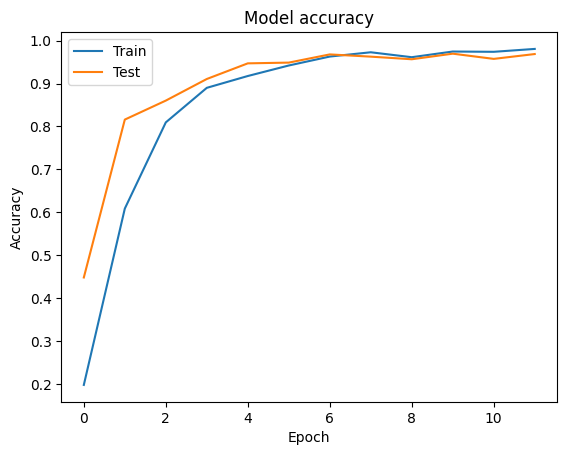

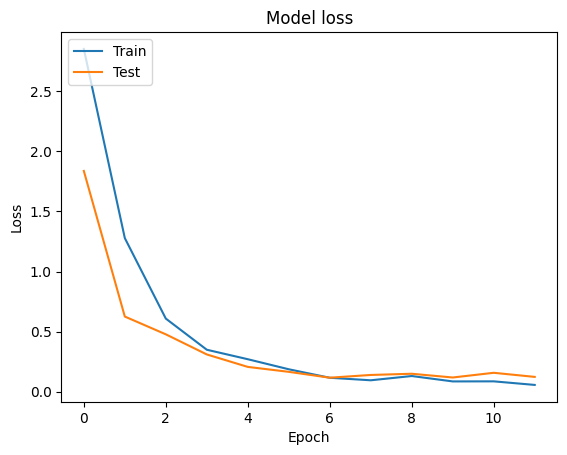

36/36 [==============================] - 4s 120ms/step
Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.85      0.91        34
         1.0       1.00      1.00      1.00        30
         2.0       0.89      0.93      0.91        27
         3.0       1.00      1.00      1.00        38
         4.0       0.89      1.00      0.94        31
         5.0       1.00      1.00      1.00        28
         6.0       1.00      1.00      1.00        34
         7.0       0.96      0.96      0.96        28
         8.0       1.00      1.00      1.00        36
         9.0       0.92      0.97      0.95        37
        10.0       1.00      0.95      0.97        37
        11.0       0.94      1.00      0.97        34
        12.0       0.93      0.96      0.95        27
        13.0       0.96      0.88      0.92        25
        14.0       1.00      0.96      0.98        27
        15.0       1.00      1.00      1.00        39
   

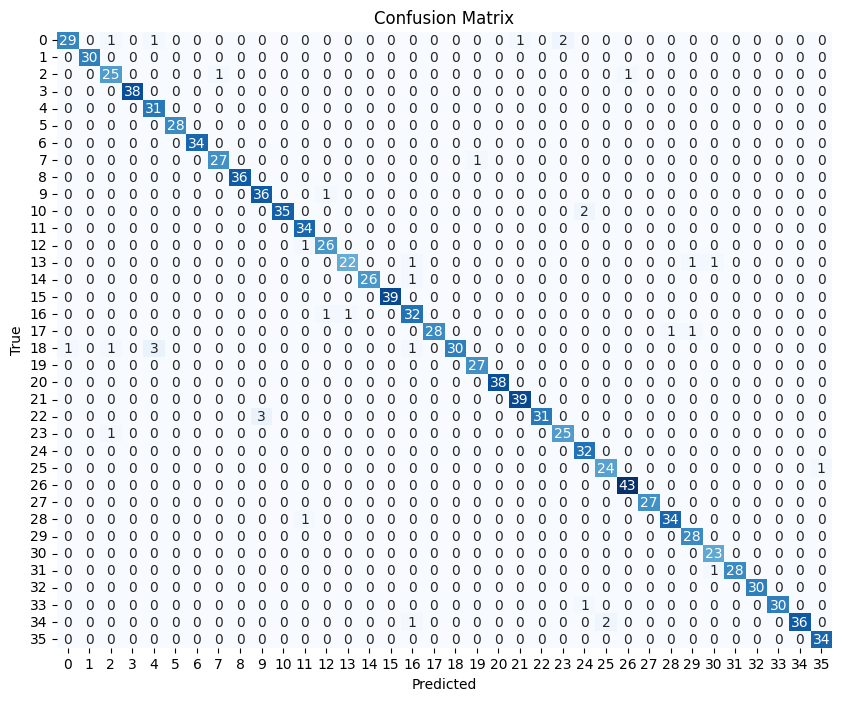

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from keras.callbacks import EarlyStopping

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/erosion + prewitt'

def load_images(dataset_path, batch_size=32):
    # Image data generator for loading images in batches with resizing and augmentation
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2  # 20% of the data will be used for validation
    )

    # Load and preprocess images using the data generator
    image_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Get the number of classes
    num_classes = image_generator.num_classes

    # Load images and labels
    images, labels = [], []
    for _ in range(len(image_generator)):
        batch_images, batch_labels = next(image_generator)
        images.extend(batch_images)
        labels.extend(batch_labels)

    return np.array(images), np.array(labels), num_classes

# Load and preprocess images
images, labels, num_classes = load_images(dataset_path)

# Split dataset into train and test sets
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)

# Define CNN model with dropout layers
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),  # Adding dropout with a rate of 0.5
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping callback
history = model.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels), callbacks=[early_stopping])

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# 1. Make Predictions
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

4. dilation + canny

Found 5760 images belonging to 36 classes.
Epoch 1/30
144/144 [==============================] - 56s 382ms/step - loss: 2.8746 - accuracy: 0.1871 - val_loss: 1.9200 - val_accuracy: 0.4158
Epoch 2/30
144/144 [==============================] - 59s 411ms/step - loss: 1.4621 - accuracy: 0.5510 - val_loss: 0.9514 - val_accuracy: 0.7144
Epoch 3/30
144/144 [==============================] - 57s 398ms/step - loss: 0.8131 - accuracy: 0.7476 - val_loss: 0.6040 - val_accuracy: 0.8151
Epoch 4/30
144/144 [==============================] - 58s 402ms/step - loss: 0.4646 - accuracy: 0.8487 - val_loss: 0.4667 - val_accuracy: 0.8637
Epoch 5/30
144/144 [==============================] - 58s 402ms/step - loss: 0.2945 - accuracy: 0.9008 - val_loss: 0.5671 - val_accuracy: 0.8464
Epoch 6/30
144/144 [==============================] - 58s 406ms/step - loss: 0.2477 - accuracy: 0.9217 - val_loss: 0.3503 - val_accuracy: 0.9045
Epoch 7/30
144/144 [==============================] - 58s 405ms/step - loss: 0.1835 - a

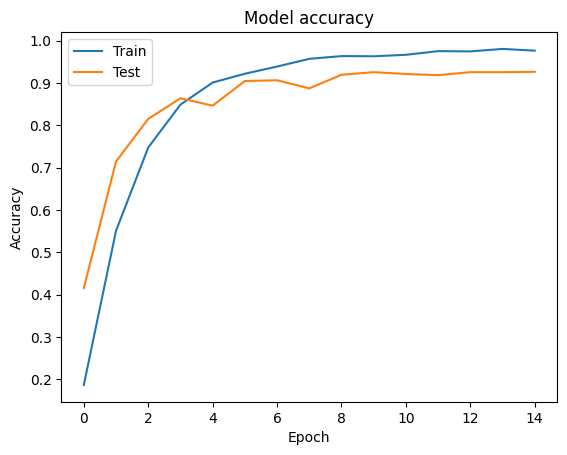

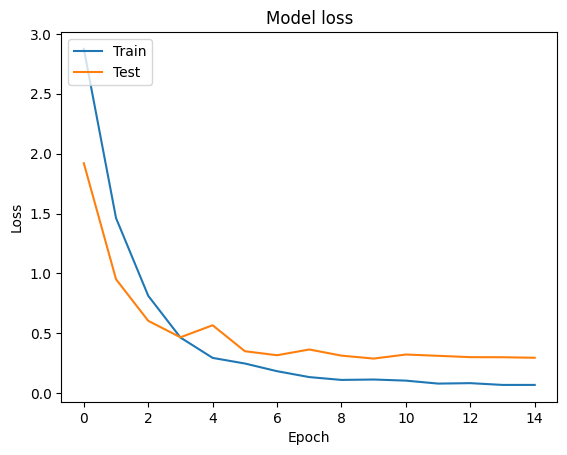

36/36 [==============================] - 4s 100ms/step
Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88        26
         1.0       1.00      0.97      0.99        38
         2.0       0.91      0.88      0.89        33
         3.0       0.95      1.00      0.97        36
         4.0       0.76      0.97      0.85        30
         5.0       0.91      1.00      0.96        32
         6.0       1.00      0.93      0.96        28
         7.0       0.94      0.89      0.92        37
         8.0       1.00      1.00      1.00        29
         9.0       0.94      1.00      0.97        29
        10.0       0.97      0.88      0.93        42
        11.0       1.00      0.87      0.93        31
        12.0       0.95      0.92      0.94        39
        13.0       0.97      0.91      0.94        35
        14.0       0.91      0.86      0.89        36
        15.0       0.80      0.97      0.88        29
   

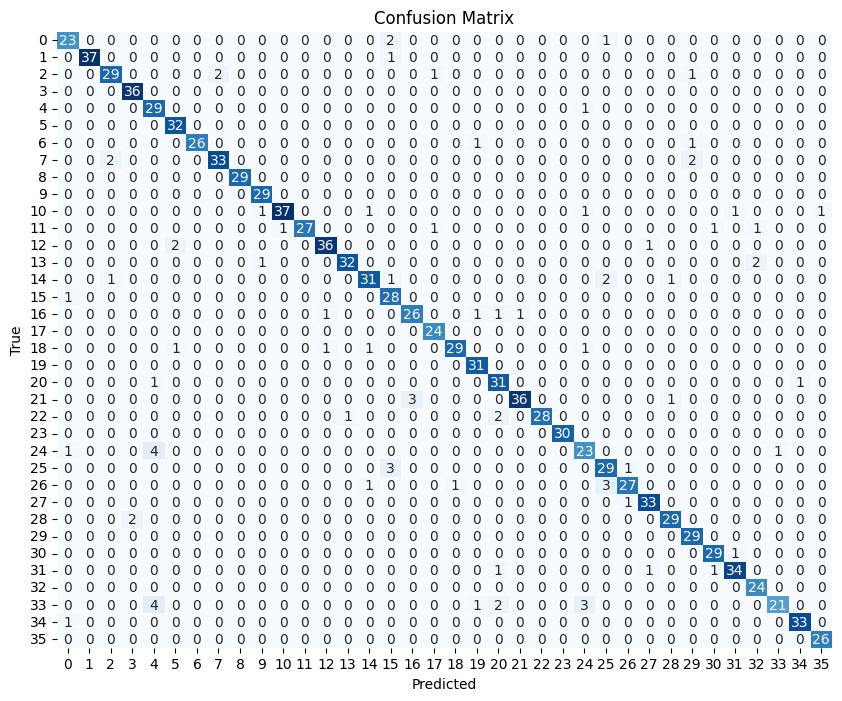

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from keras.callbacks import EarlyStopping

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/dilation + canny'

def load_images(dataset_path, batch_size=32):
    # Image data generator for loading images in batches with resizing and augmentation
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2  # 20% of the data will be used for validation
    )

    # Load and preprocess images using the data generator
    image_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Get the number of classes
    num_classes = image_generator.num_classes

    # Load images and labels
    images, labels = [], []
    for _ in range(len(image_generator)):
        batch_images, batch_labels = next(image_generator)
        images.extend(batch_images)
        labels.extend(batch_labels)

    return np.array(images), np.array(labels), num_classes

# Load and preprocess images
images, labels, num_classes = load_images(dataset_path)

# Split dataset into train and test sets
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)

# Define CNN model with dropout layers
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),  # Adding dropout with a rate of 0.5
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping callback
history = model.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels), callbacks=[early_stopping])

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# 1. Make Predictions
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

5. dilation + sobel

Found 5760 images belonging to 36 classes.
Epoch 1/30
144/144 [==============================] - 50s 343ms/step - loss: 2.8538 - accuracy: 0.1901 - val_loss: 1.6017 - val_accuracy: 0.5217
Epoch 2/30
144/144 [==============================] - 49s 340ms/step - loss: 1.4133 - accuracy: 0.5616 - val_loss: 0.8396 - val_accuracy: 0.7509
Epoch 3/30
144/144 [==============================] - 49s 343ms/step - loss: 0.6901 - accuracy: 0.7795 - val_loss: 0.4462 - val_accuracy: 0.8681
Epoch 4/30
144/144 [==============================] - 50s 345ms/step - loss: 0.3842 - accuracy: 0.8765 - val_loss: 0.2963 - val_accuracy: 0.9175
Epoch 5/30
144/144 [==============================] - 50s 347ms/step - loss: 0.2446 - accuracy: 0.9188 - val_loss: 0.2719 - val_accuracy: 0.9210
Epoch 6/30
144/144 [==============================] - 50s 347ms/step - loss: 0.1716 - accuracy: 0.9468 - val_loss: 0.2764 - val_accuracy: 0.9219
Epoch 7/30
144/144 [==============================] - 50s 344ms/step - loss: 0.1383 - a

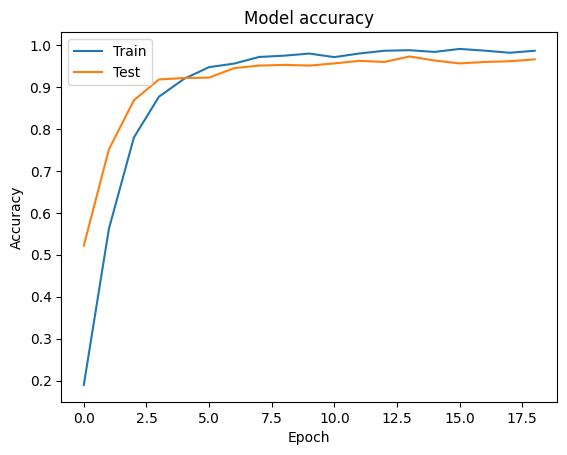

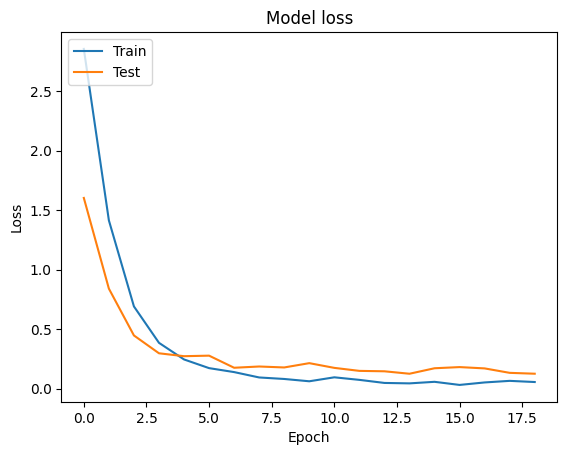

36/36 [==============================] - 4s 96ms/step
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98        33
         1.0       0.96      1.00      0.98        27
         2.0       0.97      0.97      0.97        32
         3.0       1.00      0.97      0.98        30
         4.0       0.97      1.00      0.99        35
         5.0       0.97      0.91      0.94        34
         6.0       1.00      1.00      1.00        34
         7.0       0.97      1.00      0.99        33
         8.0       0.96      0.93      0.94        27
         9.0       1.00      1.00      1.00        25
        10.0       1.00      1.00      1.00        33
        11.0       0.97      0.94      0.95        32
        12.0       0.89      0.97      0.93        33
        13.0       1.00      1.00      1.00        38
        14.0       0.94      1.00      0.97        30
        15.0       1.00      0.97      0.98        31
    

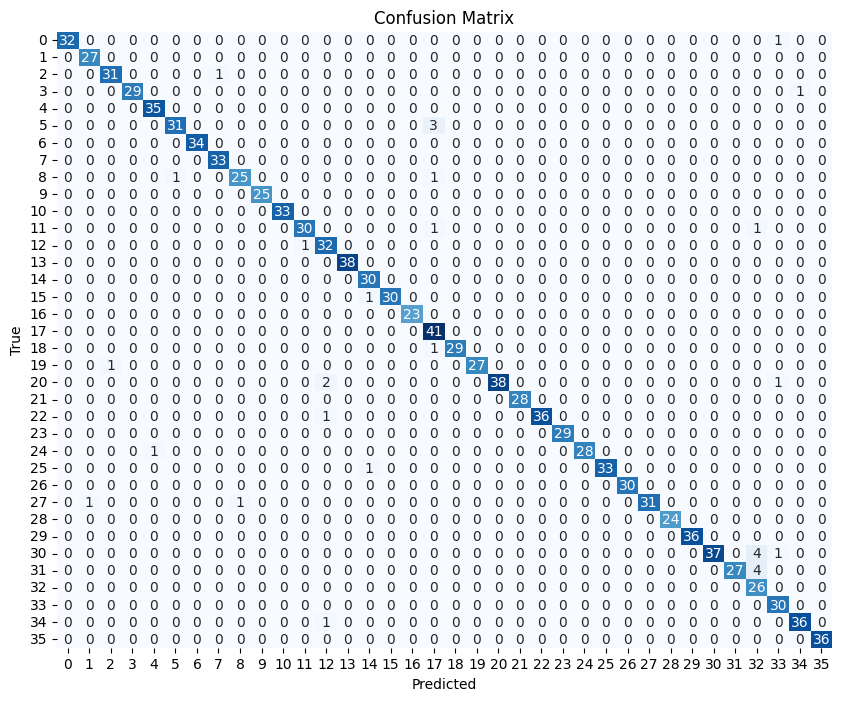

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from keras.callbacks import EarlyStopping

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/dilation + sobel'

def load_images(dataset_path, batch_size=32):
    # Image data generator for loading images in batches with resizing and augmentation
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2  # 20% of the data will be used for validation
    )

    # Load and preprocess images using the data generator
    image_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Get the number of classes
    num_classes = image_generator.num_classes

    # Load images and labels
    images, labels = [], []
    for _ in range(len(image_generator)):
        batch_images, batch_labels = next(image_generator)
        images.extend(batch_images)
        labels.extend(batch_labels)

    return np.array(images), np.array(labels), num_classes

# Load and preprocess images
images, labels, num_classes = load_images(dataset_path)

# Split dataset into train and test sets
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)

# Define CNN model with dropout layers
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),  # Adding dropout with a rate of 0.5
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping callback
history = model.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels), callbacks=[early_stopping])

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# 1. Make Predictions
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

6. dilation + prewitt

Found 5760 images belonging to 36 classes.
Epoch 1/30
144/144 [==============================] - 59s 395ms/step - loss: 2.8935 - accuracy: 0.1712 - val_loss: 1.8543 - val_accuracy: 0.4444
Epoch 2/30
144/144 [==============================] - 55s 381ms/step - loss: 1.6203 - accuracy: 0.5074 - val_loss: 1.0709 - val_accuracy: 0.6892
Epoch 3/30
144/144 [==============================] - 61s 426ms/step - loss: 0.9353 - accuracy: 0.7092 - val_loss: 0.6621 - val_accuracy: 0.8030
Epoch 4/30
144/144 [==============================] - 63s 439ms/step - loss: 0.5722 - accuracy: 0.8223 - val_loss: 0.5118 - val_accuracy: 0.8394
Epoch 5/30
144/144 [==============================] - 62s 431ms/step - loss: 0.3777 - accuracy: 0.8841 - val_loss: 0.5386 - val_accuracy: 0.8481
Epoch 6/30
144/144 [==============================] - 61s 427ms/step - loss: 0.2919 - accuracy: 0.9099 - val_loss: 0.4365 - val_accuracy: 0.8733
Epoch 7/30
144/144 [==============================] - 61s 427ms/step - loss: 0.2474 - a

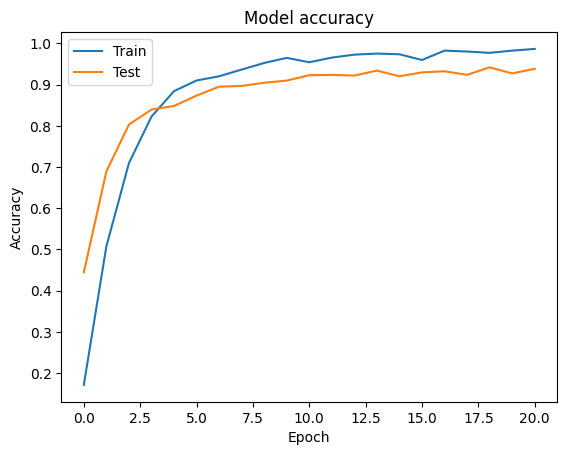

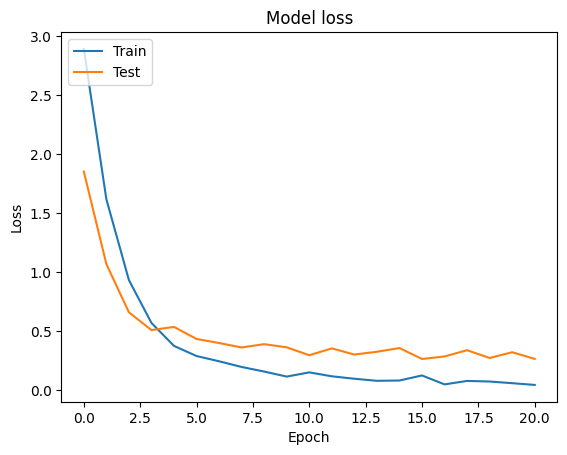

36/36 [==============================] - 4s 117ms/step
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.88      0.94        33
         1.0       0.96      0.92      0.94        24
         2.0       1.00      1.00      1.00        24
         3.0       0.94      0.85      0.89        34
         4.0       0.69      0.94      0.79        33
         5.0       0.91      0.97      0.94        30
         6.0       1.00      0.97      0.98        31
         7.0       1.00      1.00      1.00        36
         8.0       0.97      1.00      0.98        30
         9.0       0.97      0.94      0.96        34
        10.0       0.92      1.00      0.96        33
        11.0       0.94      0.94      0.94        32
        12.0       0.94      0.89      0.91        35
        13.0       1.00      1.00      1.00        30
        14.0       0.95      0.75      0.84        28
        15.0       0.87      0.98      0.92        41
   

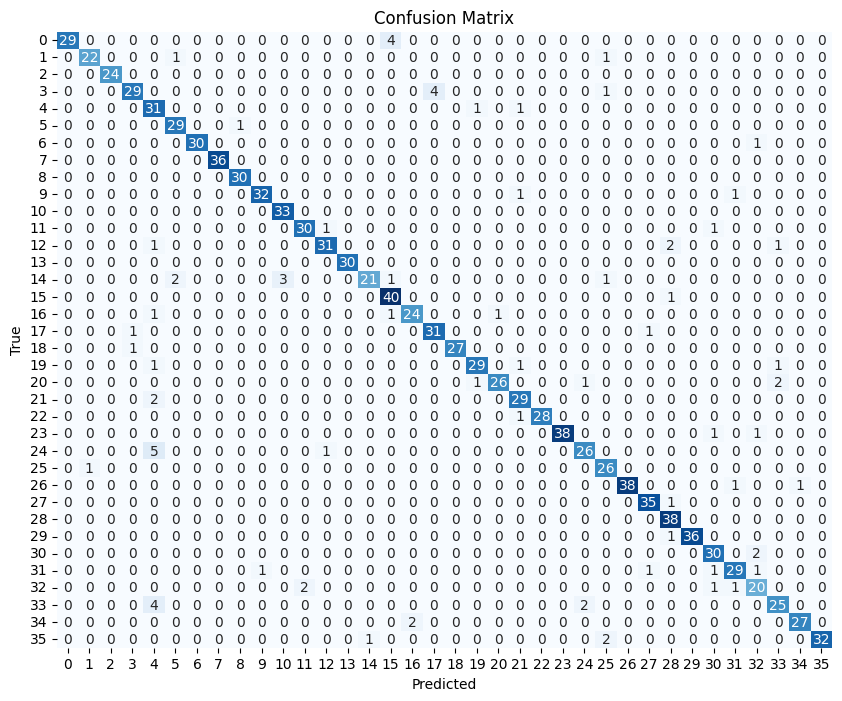

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from keras.callbacks import EarlyStopping

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/dilation + prewitt'

def load_images(dataset_path, batch_size=32):
    # Image data generator for loading images in batches with resizing and augmentation
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=0.2  # 20% of the data will be used for validation
    )

    # Load and preprocess images using the data generator
    image_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Get the number of classes
    num_classes = image_generator.num_classes

    # Load images and labels
    images, labels = [], []
    for _ in range(len(image_generator)):
        batch_images, batch_labels = next(image_generator)
        images.extend(batch_images)
        labels.extend(batch_labels)

    return np.array(images), np.array(labels), num_classes

# Load and preprocess images
images, labels, num_classes = load_images(dataset_path)

# Split dataset into train and test sets
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)

# Define CNN model with dropout layers
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),  # Adding dropout with a rate of 0.5
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Define early stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train the model with early stopping callback
history = model.fit(train_images, train_labels, epochs=30, validation_data=(test_images, test_labels), callbacks=[early_stopping])

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

# 1. Make Predictions
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## GoogleNet Model


1. erosion + canny

Found 5760 images belonging to 36 classes.
Found 1440 images belonging to 36 classes.
Epoch 1/30
180/180 [==============================] - 121s 646ms/step - loss: 0.8693 - accuracy: 0.7929 - val_loss: 0.1774 - val_accuracy: 0.9701
Epoch 2/30
180/180 [==============================] - 113s 628ms/step - loss: 0.1606 - accuracy: 0.9609 - val_loss: 0.1003 - val_accuracy: 0.9792
Epoch 3/30
180/180 [==============================] - 114s 631ms/step - loss: 0.1332 - accuracy: 0.9648 - val_loss: 0.0883 - val_accuracy: 0.9771
Epoch 4/30
180/180 [==============================] - 116s 644ms/step - loss: 0.0991 - accuracy: 0.9720 - val_loss: 0.0552 - val_accuracy: 0.9826
Epoch 5/30
180/180 [==============================] - 115s 637ms/step - loss: 0.0845 - accuracy: 0.9750 - val_loss: 0.0471 - val_accuracy: 0.9847
Epoch 6/30
180/180 [==============================] - 116s 646ms/step - loss: 0.0851 - accuracy: 0.9753 - val_loss: 0.0697 - val_accuracy: 0.9819
Epoch 7/30
180/180 [==================

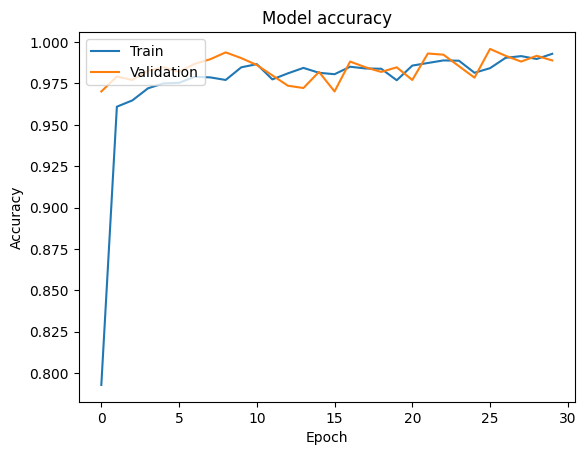

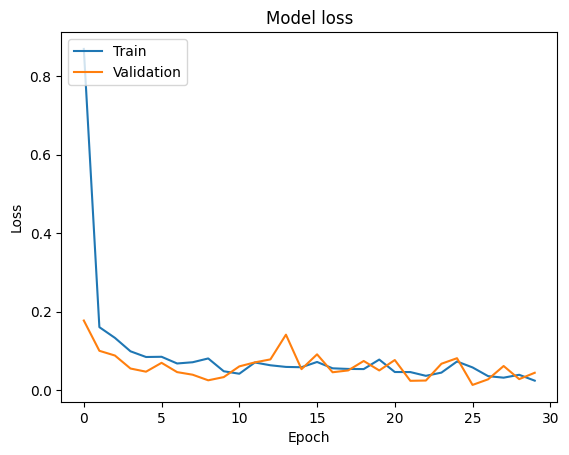

45/45 [==============================] - 23s 509ms/step - loss: 0.0343 - accuracy: 0.9910
Test loss: 0.03433923050761223
Test accuracy: 0.9909722208976746


1/1 [==============================] - 2s 2s/step
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         5
         2.0       1.00      1.00      1.00         2
         5.0       1.00      1.00      1.00         2
         6.0       1.00      1.00      1.00         1
         9.0       1.00      1.00      1.00         1
        10.0       1.00      1.00      1.00         1
        13.0       1.00      1.00      1.00         2
        14.0       1.00      1.00      1.00         1
        15.0       1.00      1.00      1.00         3
        16.0       1.00      1.00      1.00         2
        17.0       1.00      1.00      1.00         1
        18.0       1.00      1.00      1.00         1
        19.0       1.00      1.00      1.00         1
        21.0       1.00      1.00      1.00         1
        23.0       1.00      1.00      1.00         1
        24.0       1.00      1.00      1.00         1
        

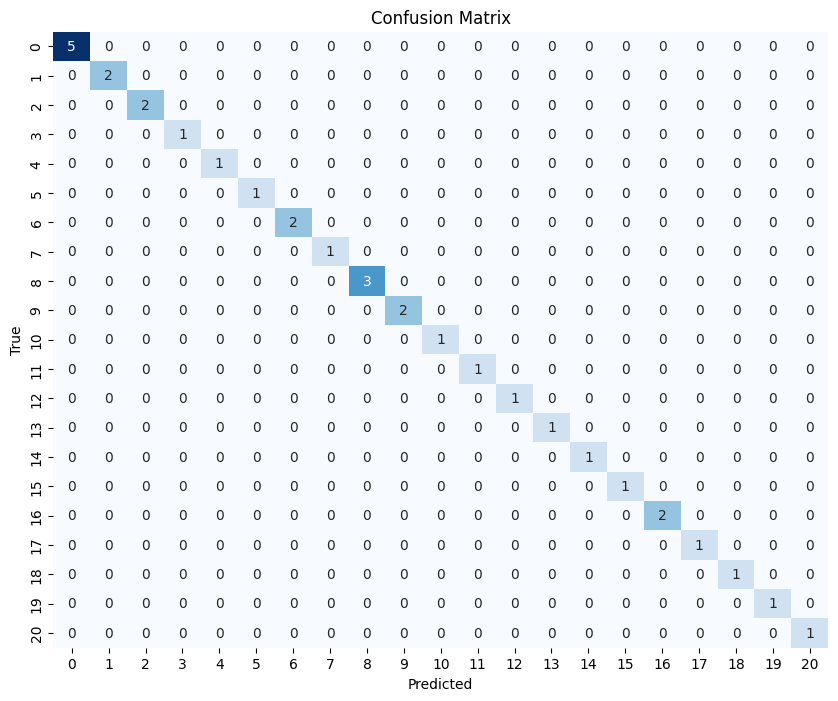

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D
from keras.applications import InceptionV3
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/erosion + canny'

def load_images(dataset_path, batch_size=32, validation_split=0.2):
    # Load and preprocess images using the data generator
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=validation_split  # Use the validation_split parameter here
    )

    # Load and preprocess images using the data generator for training
    train_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Load and preprocess images using the data generator for validation
    validation_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='validation'  # Use the validation subset
    )

    # Get the number of classes
    num_classes = train_generator.num_classes

    return train_generator, validation_generator, num_classes

# Load and preprocess images
train_generator, validation_generator, num_classes = load_images(dataset_path)

# Load InceptionV1 model without top (fully connected) layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the base model
base_model.trainable = False

# Create new model on top
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model for 30 epochs
history = model.fit(train_generator, epochs=30, validation_data=validation_generator)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model
test_loss, test_acc = model.evaluate(validation_generator)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 1. Make Predictions
test_images, test_labels = next(validation_generator)
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

2. erosion + sobel

Found 5760 images belonging to 36 classes.
Found 1440 images belonging to 36 classes.
Epoch 1/30
180/180 [==============================] - 124s 661ms/step - loss: 0.5643 - accuracy: 0.8755 - val_loss: 0.0683 - val_accuracy: 0.9833
Epoch 2/30
180/180 [==============================] - 116s 643ms/step - loss: 0.0748 - accuracy: 0.9795 - val_loss: 0.0277 - val_accuracy: 0.9937
Epoch 3/30
180/180 [==============================] - 112s 623ms/step - loss: 0.0508 - accuracy: 0.9854 - val_loss: 0.0701 - val_accuracy: 0.9792
Epoch 4/30
180/180 [==============================] - 113s 626ms/step - loss: 0.0650 - accuracy: 0.9773 - val_loss: 0.0466 - val_accuracy: 0.9875
Epoch 5/30
180/180 [==============================] - 114s 634ms/step - loss: 0.0433 - accuracy: 0.9878 - val_loss: 0.0182 - val_accuracy: 0.9951
Epoch 6/30
180/180 [==============================] - 113s 626ms/step - loss: 0.0509 - accuracy: 0.9868 - val_loss: 0.0106 - val_accuracy: 0.9979
Epoch 7/30
180/180 [==================

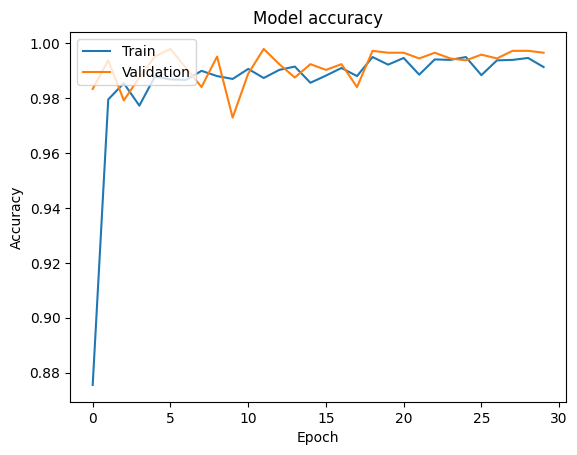

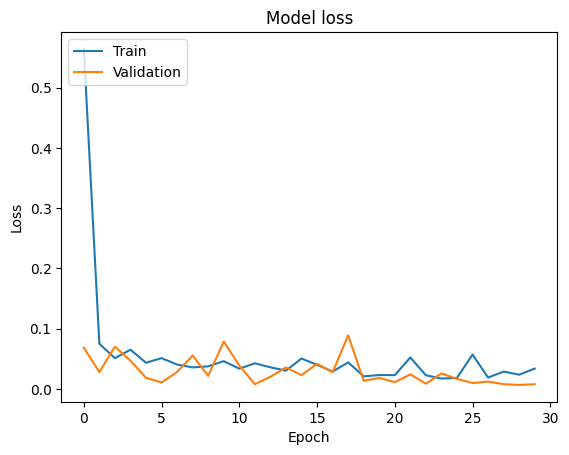

45/45 [==============================] - 22s 491ms/step - loss: 0.0042 - accuracy: 0.9986
Test loss: 0.004157458897680044
Test accuracy: 0.9986110925674438


1/1 [==============================] - 2s 2s/step
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         2.0       1.00      1.00      1.00         1
         4.0       1.00      1.00      1.00         1
         5.0       1.00      1.00      1.00         2
         8.0       1.00      1.00      1.00         1
         9.0       1.00      1.00      1.00         1
        12.0       1.00      1.00      1.00         2
        13.0       1.00      1.00      1.00         1
        14.0       1.00      1.00      1.00         1
        15.0       1.00      1.00      1.00         2
        16.0       1.00      1.00      1.00         2
        17.0       1.00      1.00      1.00         3
        19.0       1.00      1.00      1.00         1
        20.0       1.00      1.00      1.00         2
        21.0       1.00      1.00      1.00         1
        22.0       1.00      1.00      1.00         1
        

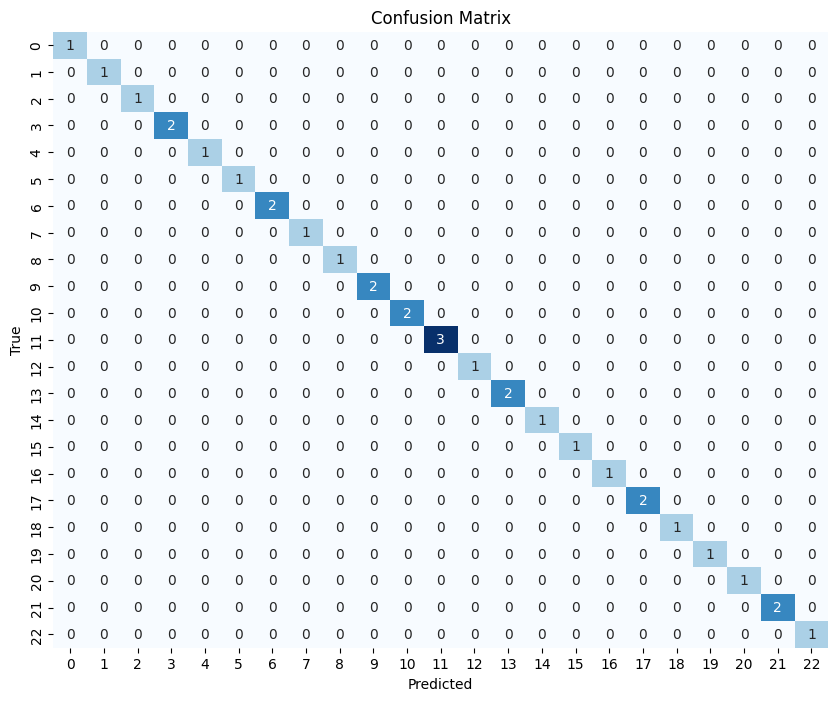

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D
from keras.applications import InceptionV3
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/erosion + sobel'

def load_images(dataset_path, batch_size=32, validation_split=0.2):
    # Load and preprocess images using the data generator
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=validation_split  # Use the validation_split parameter here
    )

    # Load and preprocess images using the data generator for training
    train_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Load and preprocess images using the data generator for validation
    validation_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='validation'  # Use the validation subset
    )

    # Get the number of classes
    num_classes = train_generator.num_classes

    return train_generator, validation_generator, num_classes

# Load and preprocess images
train_generator, validation_generator, num_classes = load_images(dataset_path)

# Load InceptionV1 model without top (fully connected) layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the base model
base_model.trainable = False

# Create new model on top
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model for 30 epochs
history = model.fit(train_generator, epochs=30, validation_data=validation_generator)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model
test_loss, test_acc = model.evaluate(validation_generator)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 1. Make Predictions
test_images, test_labels = next(validation_generator)
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

3. erosion + prewitt

Found 5760 images belonging to 36 classes.
Found 1440 images belonging to 36 classes.
Epoch 1/30
180/180 [==============================] - 1638s 9s/step - loss: 0.5471 - accuracy: 0.8854 - val_loss: 0.1244 - val_accuracy: 0.9736
Epoch 2/30
180/180 [==============================] - 115s 640ms/step - loss: 0.0965 - accuracy: 0.9804 - val_loss: 0.0584 - val_accuracy: 0.9882
Epoch 3/30
180/180 [==============================] - 115s 640ms/step - loss: 0.0606 - accuracy: 0.9856 - val_loss: 0.0586 - val_accuracy: 0.9833
Epoch 4/30
180/180 [==============================] - 116s 644ms/step - loss: 0.0428 - accuracy: 0.9887 - val_loss: 0.0477 - val_accuracy: 0.9917
Epoch 5/30
180/180 [==============================] - 115s 641ms/step - loss: 0.0408 - accuracy: 0.9896 - val_loss: 0.0292 - val_accuracy: 0.9924
Epoch 6/30
180/180 [==============================] - 115s 639ms/step - loss: 0.0500 - accuracy: 0.9880 - val_loss: 0.0521 - val_accuracy: 0.9868
Epoch 7/30
180/180 [====================

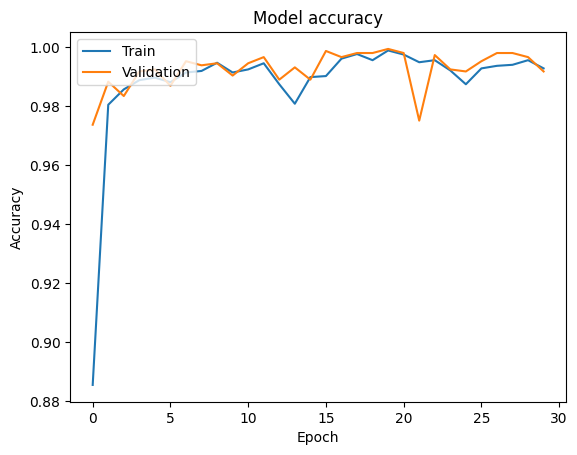

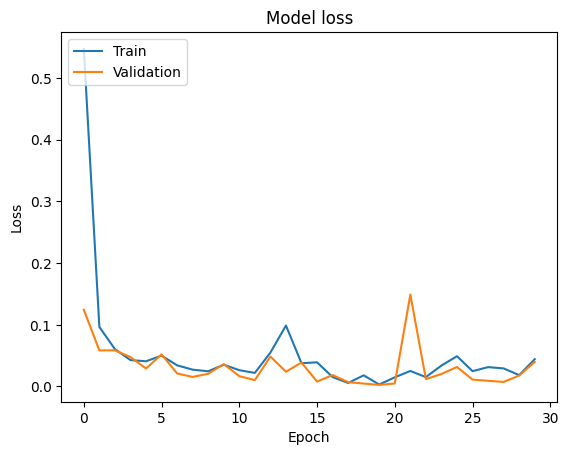

45/45 [==============================] - 24s 523ms/step - loss: 0.0396 - accuracy: 0.9917
Test loss: 0.03962365910410881
Test accuracy: 0.9916666746139526
1/1 [==============================] - 2s 2s/step
Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00         1
         3.0       1.00      1.00      1.00         3
         5.0       1.00      1.00      1.00         1
         6.0       1.00      1.00      1.00         1
         7.0       1.00      1.00      1.00         1
        10.0       1.00      1.00      1.00         1
        16.0       1.00      1.00      1.00         1
        17.0       1.00      1.00      1.00         1
        18.0       1.00      1.00      1.00         1
        19.0       1.00      1.00      1.00         1
        20.0       1.00      1.00      1.00         2
        21.0       1.00      1.00      1.00         1
        23.0       1.00      1.00      1.00         3
        24.0   

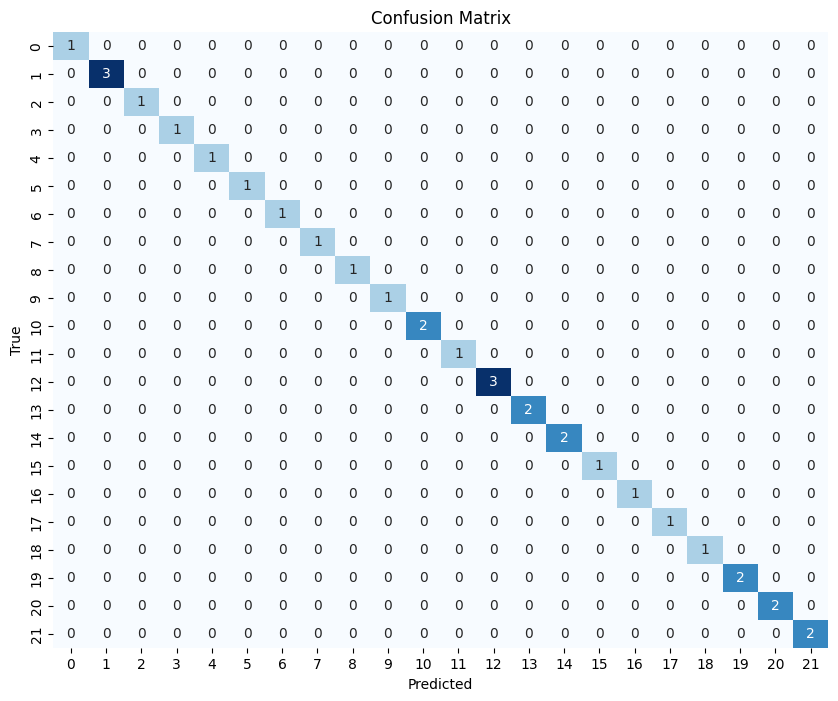

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D
from keras.applications import InceptionV3
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/erosion + prewitt'

def load_images(dataset_path, batch_size=32, validation_split=0.2):
    # Load and preprocess images using the data generator
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=validation_split  # Use the validation_split parameter here
    )

    # Load and preprocess images using the data generator for training
    train_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Load and preprocess images using the data generator for validation
    validation_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='validation'  # Use the validation subset
    )

    # Get the number of classes
    num_classes = train_generator.num_classes

    return train_generator, validation_generator, num_classes

# Load and preprocess images
train_generator, validation_generator, num_classes = load_images(dataset_path)

# Load InceptionV1 model without top (fully connected) layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the base model
base_model.trainable = False

# Create new model on top
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model for 30 epochs
history = model.fit(train_generator, epochs=30, validation_data=validation_generator)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model
test_loss, test_acc = model.evaluate(validation_generator)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 1. Make Predictions
test_images, test_labels = next(validation_generator)
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

4. dilation + canny

Found 5760 images belonging to 36 classes.
Found 1440 images belonging to 36 classes.
Epoch 1/30
180/180 [==============================] - 365s 2s/step - loss: 1.0038 - accuracy: 0.7615 - val_loss: 0.3384 - val_accuracy: 0.9153
Epoch 2/30
180/180 [==============================] - 132s 733ms/step - loss: 0.2908 - accuracy: 0.9252 - val_loss: 0.1799 - val_accuracy: 0.9500
Epoch 3/30
180/180 [==============================] - 115s 638ms/step - loss: 0.1843 - accuracy: 0.9493 - val_loss: 0.1456 - val_accuracy: 0.9646
Epoch 4/30
180/180 [==============================] - 114s 635ms/step - loss: 0.1374 - accuracy: 0.9613 - val_loss: 0.1359 - val_accuracy: 0.9625
Epoch 5/30
180/180 [==============================] - 117s 649ms/step - loss: 0.1043 - accuracy: 0.9708 - val_loss: 0.1098 - val_accuracy: 0.9688
Epoch 6/30
180/180 [==============================] - 115s 640ms/step - loss: 0.1277 - accuracy: 0.9635 - val_loss: 0.0960 - val_accuracy: 0.9729
Epoch 7/30
180/180 [=====================

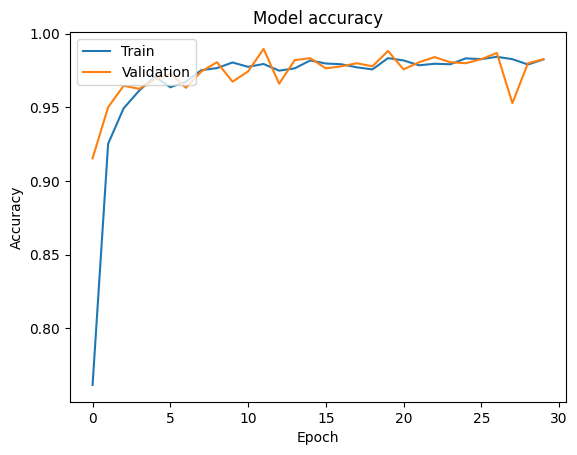

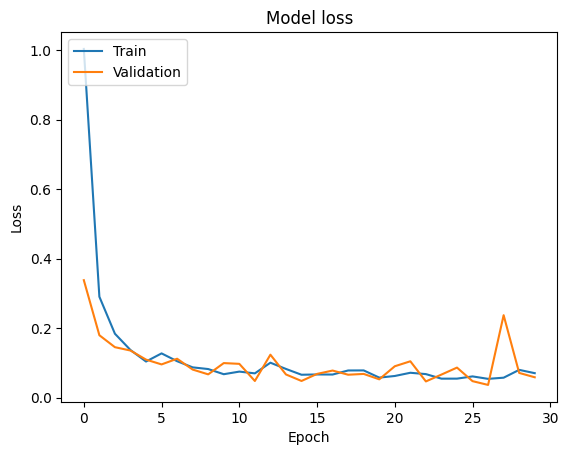

45/45 [==============================] - 23s 512ms/step - loss: 0.0409 - accuracy: 0.9896
Test loss: 0.04085814580321312
Test accuracy: 0.9895833134651184
1/1 [==============================] - 2s 2s/step
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         2.0       1.00      1.00      1.00         2
         3.0       1.00      1.00      1.00         1
         4.0       1.00      1.00      1.00         1
         6.0       1.00      1.00      1.00         1
         8.0       1.00      1.00      1.00         1
         9.0       1.00      1.00      1.00         1
        10.0       1.00      1.00      1.00         1
        11.0       1.00      1.00      1.00         2
        12.0       1.00      1.00      1.00         1
        13.0       1.00      1.00      1.00         1
        14.0       1.00      1.00      1.00         1
        16.0       1.00      1.00      1.00         1
        18.0   

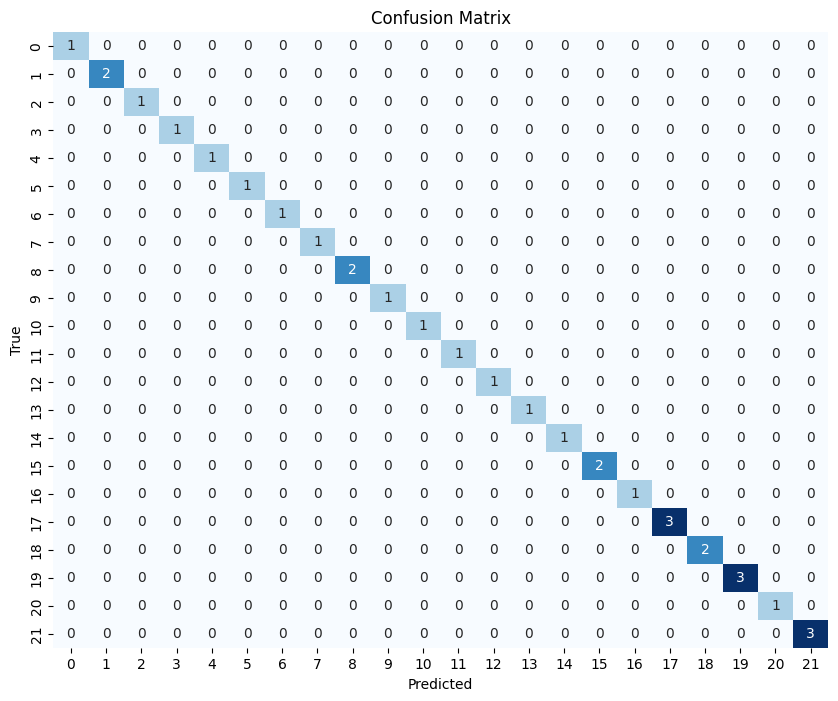

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D
from keras.applications import InceptionV3
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/dilation + canny'

def load_images(dataset_path, batch_size=32, validation_split=0.2):
    # Load and preprocess images using the data generator
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=validation_split  # Use the validation_split parameter here
    )

    # Load and preprocess images using the data generator for training
    train_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Load and preprocess images using the data generator for validation
    validation_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='validation'  # Use the validation subset
    )

    # Get the number of classes
    num_classes = train_generator.num_classes

    return train_generator, validation_generator, num_classes

# Load and preprocess images
train_generator, validation_generator, num_classes = load_images(dataset_path)

# Load InceptionV1 model without top (fully connected) layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the base model
base_model.trainable = False

# Create new model on top
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model for 30 epochs
history = model.fit(train_generator, epochs=30, validation_data=validation_generator)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model
test_loss, test_acc = model.evaluate(validation_generator)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 1. Make Predictions
test_images, test_labels = next(validation_generator)
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


5. dilation + sobel

Found 5760 images belonging to 36 classes.
Found 1440 images belonging to 36 classes.
Epoch 1/30
180/180 [==============================] - 124s 656ms/step - loss: 0.5661 - accuracy: 0.8674 - val_loss: 0.2548 - val_accuracy: 0.9431
Epoch 2/30
180/180 [==============================] - 115s 638ms/step - loss: 0.1105 - accuracy: 0.9741 - val_loss: 0.1141 - val_accuracy: 0.9667
Epoch 3/30
180/180 [==============================] - 115s 638ms/step - loss: 0.0909 - accuracy: 0.9760 - val_loss: 0.0815 - val_accuracy: 0.9826
Epoch 4/30
180/180 [==============================] - 115s 641ms/step - loss: 0.0675 - accuracy: 0.9812 - val_loss: 0.0604 - val_accuracy: 0.9799
Epoch 5/30
180/180 [==============================] - 133s 741ms/step - loss: 0.0364 - accuracy: 0.9903 - val_loss: 0.0372 - val_accuracy: 0.9889
Epoch 6/30
180/180 [==============================] - 116s 642ms/step - loss: 0.0511 - accuracy: 0.9868 - val_loss: 0.0323 - val_accuracy: 0.9917
Epoch 7/30
180/180 [==================

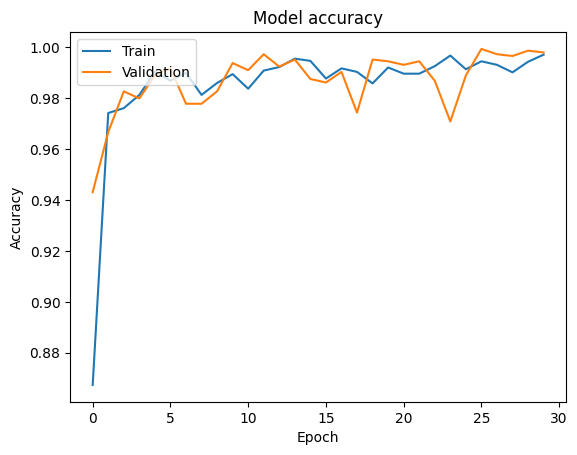

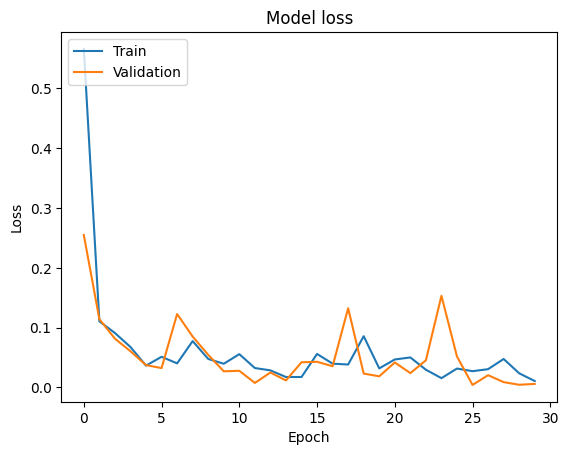

45/45 [==============================] - 23s 504ms/step - loss: 0.0091 - accuracy: 0.9979
Test loss: 0.009084859862923622
Test accuracy: 0.9979166388511658
1/1 [==============================] - 2s 2s/step
Classification Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00         1
         2.0       1.00      1.00      1.00         1
         3.0       1.00      1.00      1.00         1
         5.0       1.00      1.00      1.00         2
         6.0       1.00      1.00      1.00         2
         7.0       1.00      1.00      1.00         1
         8.0       1.00      1.00      1.00         1
         9.0       1.00      1.00      1.00         3
        12.0       1.00      1.00      1.00         1
        13.0       1.00      1.00      1.00         1
        14.0       1.00      1.00      1.00         1
        15.0       1.00      1.00      1.00         1
        16.0       1.00      1.00      1.00         1
        17.0  

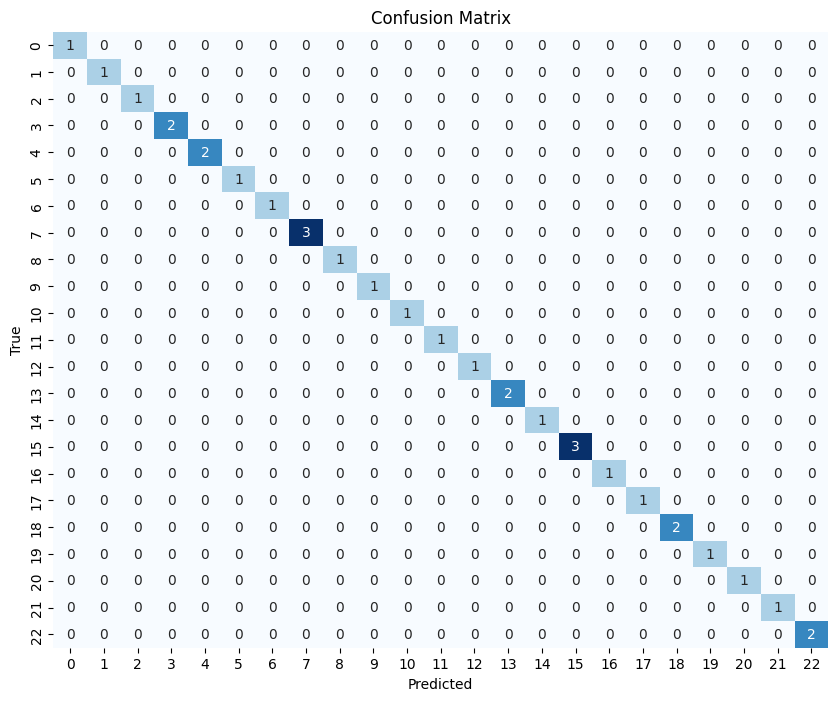

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D
from keras.applications import InceptionV3
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/dilation + sobel'

def load_images(dataset_path, batch_size=32, validation_split=0.2):
    # Load and preprocess images using the data generator
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=validation_split  # Use the validation_split parameter here
    )

    # Load and preprocess images using the data generator for training
    train_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Load and preprocess images using the data generator for validation
    validation_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='validation'  # Use the validation subset
    )

    # Get the number of classes
    num_classes = train_generator.num_classes

    return train_generator, validation_generator, num_classes

# Load and preprocess images
train_generator, validation_generator, num_classes = load_images(dataset_path)

# Load InceptionV1 model without top (fully connected) layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the base model
base_model.trainable = False

# Create new model on top
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model for 30 epochs
history = model.fit(train_generator, epochs=30, validation_data=validation_generator)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model
test_loss, test_acc = model.evaluate(validation_generator)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 1. Make Predictions
test_images, test_labels = next(validation_generator)
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

6. dilation + prewitt

Found 5760 images belonging to 36 classes.
Found 1440 images belonging to 36 classes.
Epoch 1/30
180/180 [==============================] - 1514s 8s/step - loss: 0.8722 - accuracy: 0.8200 - val_loss: 0.2368 - val_accuracy: 0.9646
Epoch 2/30
180/180 [==============================] - 116s 641ms/step - loss: 0.1781 - accuracy: 0.9641 - val_loss: 0.1197 - val_accuracy: 0.9812
Epoch 3/30
180/180 [==============================] - 114s 632ms/step - loss: 0.0874 - accuracy: 0.9814 - val_loss: 0.0769 - val_accuracy: 0.9847
Epoch 4/30
180/180 [==============================] - 114s 636ms/step - loss: 0.0848 - accuracy: 0.9830 - val_loss: 0.1656 - val_accuracy: 0.9708
Epoch 5/30
180/180 [==============================] - 114s 631ms/step - loss: 0.1002 - accuracy: 0.9823 - val_loss: 0.0389 - val_accuracy: 0.9924
Epoch 6/30
180/180 [==============================] - 114s 631ms/step - loss: 0.0450 - accuracy: 0.9901 - val_loss: 0.0304 - val_accuracy: 0.9924
Epoch 7/30
180/180 [====================

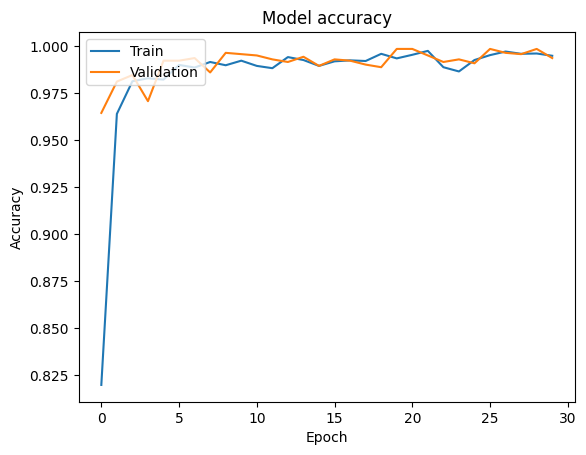

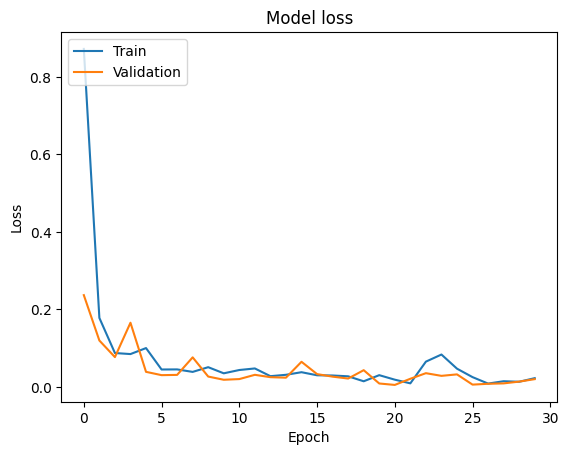

45/45 [==============================] - 23s 507ms/step - loss: 0.0502 - accuracy: 0.9937
Test loss: 0.05016852915287018
Test accuracy: 0.9937499761581421
1/1 [==============================] - 2s 2s/step
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00         1
         1.0       1.00      1.00      1.00         1
         2.0       1.00      1.00      1.00         1
         3.0       1.00      1.00      1.00         1
         6.0       1.00      1.00      1.00         1
         7.0       1.00      1.00      1.00         2
         9.0       1.00      1.00      1.00         3
        12.0       1.00      1.00      1.00         2
        14.0       1.00      1.00      1.00         2
        15.0       1.00      1.00      1.00         2
        16.0       1.00      1.00      1.00         1
        22.0       1.00      1.00      1.00         2
        23.0       1.00      1.00      1.00         2
        24.0   

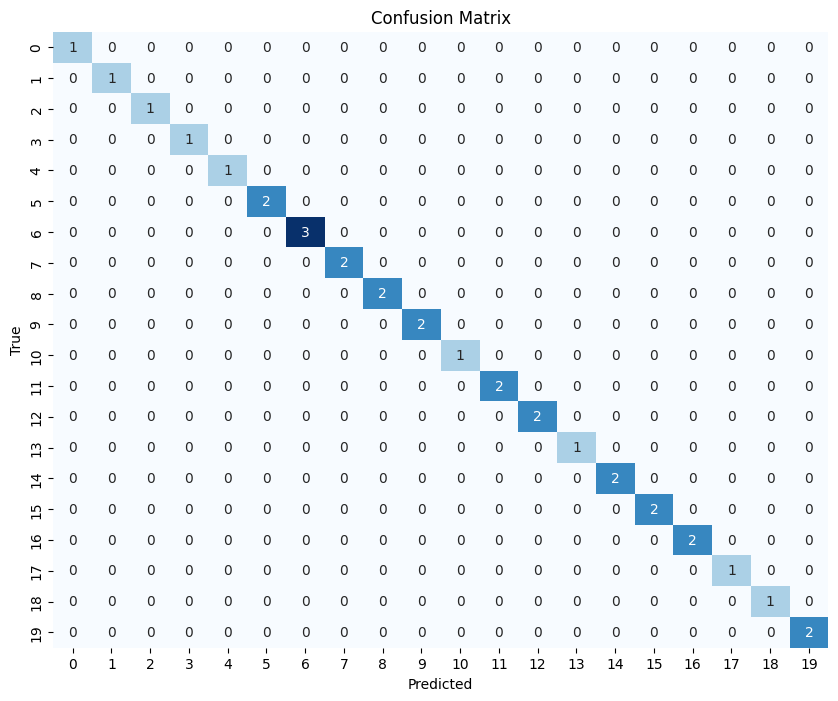

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, GlobalAveragePooling2D
from keras.applications import InceptionV3
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define dataset path
dataset_path = '/content/drive/MyDrive/DIP Project/dilation + prewitt'

def load_images(dataset_path, batch_size=32, validation_split=0.2):
    # Load and preprocess images using the data generator
    datagen = ImageDataGenerator(
        rescale=1./255,  # Normalize pixel values to [0, 1]
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        validation_split=validation_split  # Use the validation_split parameter here
    )

    # Load and preprocess images using the data generator for training
    train_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='training'  # Use the training subset
    )

    # Load and preprocess images using the data generator for validation
    validation_generator = datagen.flow_from_directory(
        dataset_path,
        target_size=(150, 150),  # Image input size suitable for InceptionV1
        batch_size=batch_size,
        class_mode='sparse',
        subset='validation'  # Use the validation subset
    )

    # Get the number of classes
    num_classes = train_generator.num_classes

    return train_generator, validation_generator, num_classes

# Load and preprocess images
train_generator, validation_generator, num_classes = load_images(dataset_path)

# Load InceptionV1 model without top (fully connected) layers
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# Freeze the base model
base_model.trainable = False

# Create new model on top
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model for 30 epochs
history = model.fit(train_generator, epochs=30, validation_data=validation_generator)

# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Evaluate the model
test_loss, test_acc = model.evaluate(validation_generator)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

# 1. Make Predictions
test_images, test_labels = next(validation_generator)
predicted_labels = model.predict(test_images)
predicted_classes = np.argmax(predicted_labels, axis=1)

# 2. Calculate Metrics
print("Classification Report:")
print(classification_report(test_labels, predicted_classes))

# 3. Plot Confusion Matrix
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()






